# Operações Lógicas e Aritméticas — Aula 4

## Objetivo
Explorar operações aritméticas (soma, subtração, multiplicação e divisão) e lógicas (AND, OR, XOR, NOT) sobre imagens monocromáticas e binárias, analisando transformações no espaço de intensidade e mascaramento de regiões.

## Conteúdo Programático
1. **Experimento 1**: Transformação de espaço de intensidade em imagem monocromática (`mandril.tif`):
   - Obtenção do negativo da imagem.
   - Normalização/ajuste de contraste para o intervalo `[100, 200]`.
2. **Experimento 2**: Ajustes de brilho, contraste e negativo por combinação aritmética:
   - Combinação de imagens para alteração visual.
   - Aplicação de normalização `[100, 200]` e aumento de contraste.
3. **Experimento 3**: Combinações lógicas (AND, OR, XOR, NOT) usando as imagens `quadrado` e `tesoura`.

## Base de Dados
- Entradas em `data/input/` (`mandril.tif`, `quadrado.png`, `tesoura.png`)
- Saídas geradas em `data/output/` (ignorado pelo Git)

## Material de Referência
- PDF da Aula 4: `docs/slides/Aula 04  - Operações Lógicas e Aritméticas.pdf`
- Documentação OpenCV: [Arithmetic Operations](https://docs.opencv.org/4.x/d0/d86/tutorial_py_image_arithmetics.html)

## Parte 0: Setup e Verificação do Ambiente

Ative o ambiente virtual antes de iniciar e utilize o kernel **PDI (.venv)**.

In [1]:
# Setup de Caminhos e Ambiente
import sys
from pathlib import Path


import cv2
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
# Ajuste caso o notebook esteja sendo executado de outra pasta
if not (ROOT / "data" / "input").exists():
    candidate = ROOT / "experiment" / "Aula 4"
    if (candidate / "data" / "input").exists():
        ROOT = candidate

INPUT_DIR = ROOT / "data" / "input"
OUTPUT_DIR = ROOT / "data" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MANDRIL_PATH = INPUT_DIR / "mandril.tif"
QUADRADO_PATH = INPUT_DIR / "quadrado.png"
TESOURA_PATH = INPUT_DIR / "tesoura.png"

print(f"[INFO] ROOT: {ROOT}")
print(f"[INFO] Diretorio de Entrada: {INPUT_DIR}")
print(f"[OK] Diretorio de Saida pronto: {OUTPUT_DIR}")

[INFO] ROOT: c:\dev\digital-image-processing\experiment\Aula 4
[INFO] Diretorio de Entrada: c:\dev\digital-image-processing\experiment\Aula 4\data\input
[OK] Diretorio de Saida pronto: c:\dev\digital-image-processing\experiment\Aula 4\data\output


**Respostas:**

- **Setup verificado:** O ambiente virtual `.venv` está ativado, OpenCV (`cv2`), `numpy` e `matplotlib` foram importados com sucesso, e os caminhos para as imagens de entrada (`mandril.tif`, `quadrado.png`, `tesoura.png`) e diretório de saída (`data/output/`) foram configurados corretamente.


## Parte 1: Experimento 1 — Transformação de Intensidade (Negativo e Escalonamento)

**Roteiro:**
1. Carregar a imagem `mandril.tif` em escala de cinza.
2. Gerar o negativo da imagem (inversão linear dos tons: `255 - pixel`).
3. Ajustar o intervalo de intensidades original para a faixa `[100, 200]` através da fórmula de mapeamento linear.

**Tarefa:**
- Implemente e plote a imagem original, seu negativo e a versão com escala reduzida para `[100, 200]`.
- Responda: O que ocorre com o contraste visual no intervalo `[100, 200]`? Por que o negativo inverte os tons?

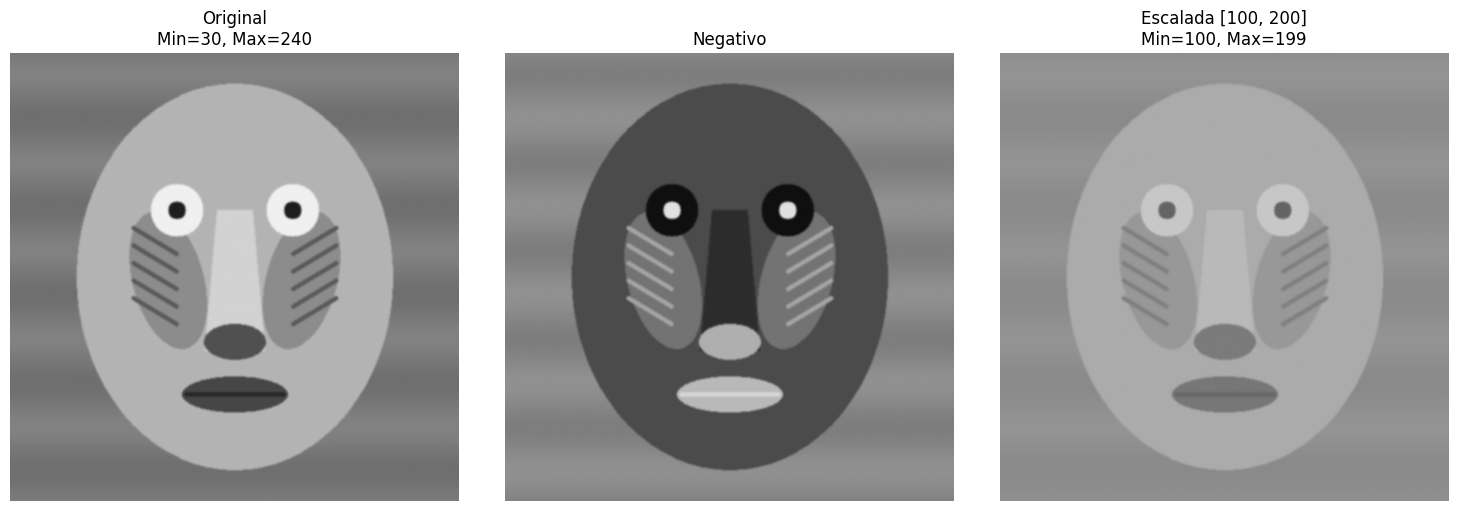

[OK] Imagens salvas em c:\dev\digital-image-processing\experiment\Aula 4\data\output


In [2]:
# Carregar imagem monocromatica
img_mandril = cv2.imread(str(MANDRIL_PATH), cv2.IMREAD_GRAYSCALE)
if img_mandril is None:
    raise FileNotFoundError(f"Imagem nao encontrada: {MANDRIL_PATH}")

# a) Obter o negativo da imagem
img_negativo = 255 - img_mandril

# b) Converter o intervalo de intensidades para [100, 200]
# Formula de normalizacao linear:
# Out = OutMin + (In - InMin) * (OutMax - OutMin) / (InMax - InMin)
in_min, in_max = img_mandril.min(), img_mandril.max()
out_min, out_max = 100.0, 200.0
img_escalada = out_min + (img_mandril.astype(float) - in_min) * (out_max - out_min) / (in_max - in_min + 1e-5)
img_escalada = np.clip(img_escalada, 100, 200).astype(np.uint8)

# Exibicao das imagens
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_mandril, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f"Original\nMin={img_mandril.min()}, Max={img_mandril.max()}")
axes[0].axis('off')

axes[1].imshow(img_negativo, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Negativo")
axes[1].axis('off')

axes[2].imshow(img_escalada, cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f"Escalada [100, 200]\nMin={img_escalada.min()}, Max={img_escalada.max()}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Salvar resultados
cv2.imwrite(str(OUTPUT_DIR / "mandril_negativo.png"), img_negativo)
cv2.imwrite(str(OUTPUT_DIR / "mandril_escalado.png"), img_escalada)
print(f"[OK] Imagens salvas em {OUTPUT_DIR}")

**Respostas:**

- **Contraste no intervalo [100, 200]:** O contraste visual diminui drasticamente. Como a imagem original aproveitava uma faixa de intensidade maior (próxima de [0, 255]), a redução da faixa dinâmica para [100, 200] comprime a variação dos tons de cinza. A imagem resultante fica acinzentada, sem tons pretos puros ou brancos puros, resultando em baixo contraste.

- **Inversão de tons pelo negativo:** Porque a operação aplicada é $f(p) = 255 - p$. Isso inverte linearmente os valores: pixels totalmente pretos (0) tornam-se totalmente brancos (255) e vice-versa. Matematicamente, a inclinação negativa da reta de transferência inverte a ordem de brilho da imagem.


## Parte 2: Experimento 2 — Combinação de Imagens, Brilho e Contraste

**Roteiro:**
1. Criar ou carregar uma segunda imagem de mesmo tamanho que o Mandril (ex: um gradiente linear ou ruído).
2. Combinar as duas imagens (média aritmética/blending) para gerar uma imagem resultante.
3. Mostrar:
   - A imagem combinada original.
   - A combinada normalizada na faixa `[100, 200]`.
   - A combinada com aumento de contraste (equalização de histograma ou CLAHE).

**Tarefa:**
- Como a soma de imagens altera o brilho resultante? E como a equalização global afeta a visualização comparada à normalização restrita?

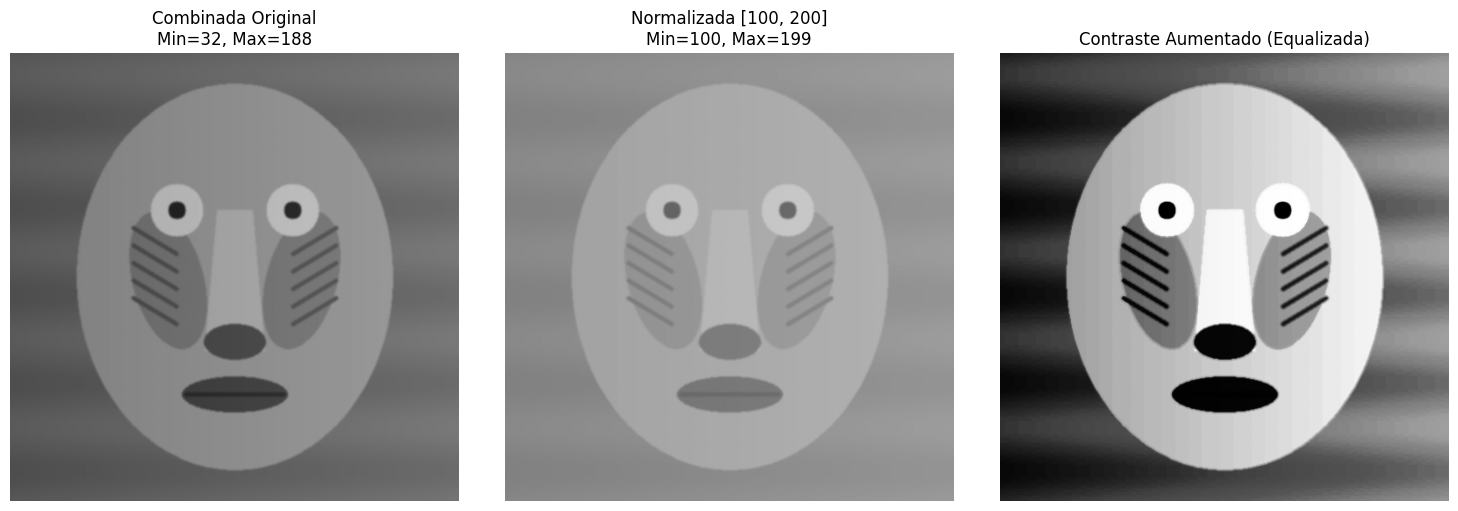

[OK] Imagens salvas em c:\dev\digital-image-processing\experiment\Aula 4\data\output


In [3]:
# Criar uma imagem de mesmo tamanho que o mandril com um gradiente horizontal
h, w = img_mandril.shape
gradiente_h = np.tile(np.linspace(0, 100, w, dtype=np.uint8), (h, 1))

# Combinar as duas imagens usando cv2.addWeighted (blending)
# f_comb = 0.7 * Mandril + 0.3 * Gradiente
img_combinada = cv2.addWeighted(img_mandril, 0.7, gradiente_h, 0.3, 0)

# Normalizar a combinada entre 100 e 200
c_min, c_max = img_combinada.min(), img_combinada.max()
img_comb_norm = 100.0 + (img_combinada.astype(float) - c_min) * 100.0 / (c_max - c_min + 1e-5)
img_comb_norm = np.clip(img_comb_norm, 100, 200).astype(np.uint8)

# Aumentar o contraste usando Equalizacao de Histograma Global
img_comb_eq = cv2.equalizeHist(img_combinada)

# Exibicao
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_combinada, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f"Combinada Original\nMin={img_combinada.min()}, Max={img_combinada.max()}")
axes[0].axis('off')

axes[1].imshow(img_comb_norm, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f"Normalizada [100, 200]\nMin={img_comb_norm.min()}, Max={img_comb_norm.max()}")
axes[1].axis('off')

axes[2].imshow(img_comb_eq, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Contraste Aumentado (Equalizada)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Salvar resultados
cv2.imwrite(str(OUTPUT_DIR / "combinada_original.png"), img_combinada)
cv2.imwrite(str(OUTPUT_DIR / "combinada_normalizada.png"), img_comb_norm)
cv2.imwrite(str(OUTPUT_DIR / "combinada_equalizada.png"), img_comb_eq)
print(f"[OK] Imagens salvas em {OUTPUT_DIR}")

**Respostas:**

- **Soma e o brilho resultante:** A soma (ou média ponderada/blending, no caso `cv2.addWeighted`) combina as intensidades luminosas de ambas as imagens. Como é uma combinação convexa de intensidades ($0.7 \times Mandril + 0.3 \times Gradiente$), o brilho resultante é uma média ponderada dos brilhos locais, introduzindo a iluminação do gradiente (mais clara à direita) sobre a estrutura do Mandril. Se fosse uma soma aritmética simples sem saturação ($A + B$), o brilho aumentaria globalmente (podendo saturar os pixels em 255).

- **Equalização global vs normalização restrita:** A equalização global redistribui os níveis de cinza da imagem combinada para tentar ocupar toda a faixa $[0, 255]$ de forma mais uniforme, o que aumenta significativamente o contraste e destaca detalhes de textura finos do Mandril. Em contrapartida, a normalização restrita comprime os valores da imagem combinada para o intervalo $[100, 200]$, resultando em uma imagem opaca, de baixo contraste e difícil visualização de pequenos detalhes.


## Parte 3: Experimento 3 — Combinações Lógicas (Máscaras Binárias)

**Roteiro:**
1. Carregar as imagens binárias `quadrado.png` e `tesoura.png`.
2. Aplicar as operações lógicas bit a bit (bitwise): AND, OR, XOR e NOT (sobre uma das entradas).
3. Exibir lado a lado as entradas e os resultados das 4 operações.

**Tarefa:**
- Explique a diferença de comportamento prático entre a operação OR e XOR.
- Em quais cenários de processamento de imagens reais a operação lógica AND é utilizada como máscara?

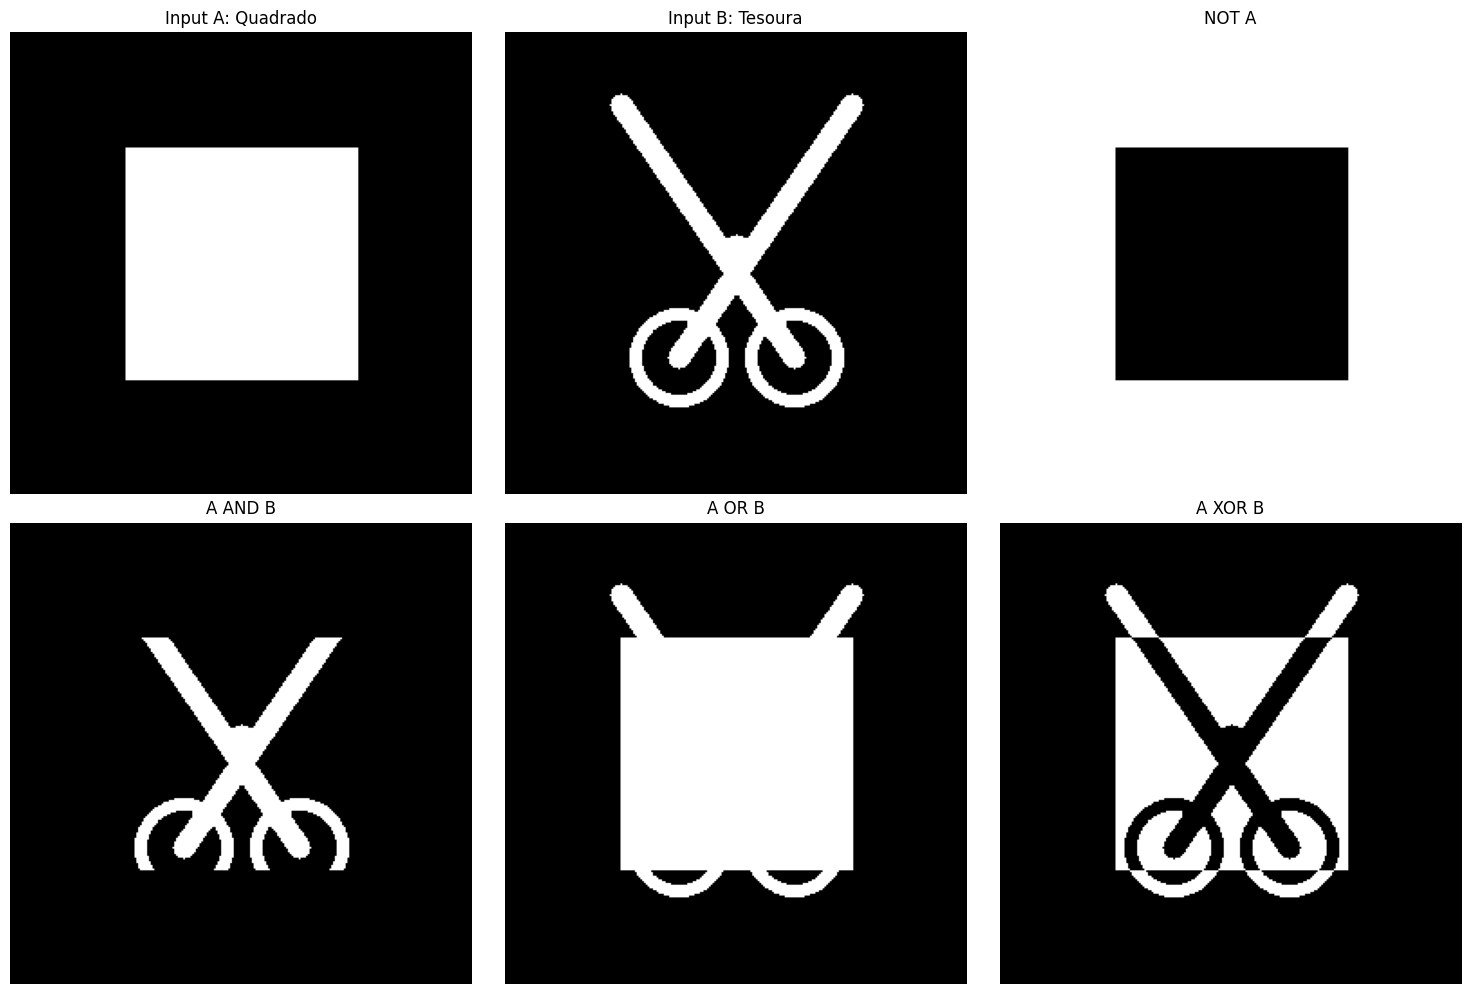

[OK] Resultados logicos salvos em c:\dev\digital-image-processing\experiment\Aula 4\data\output


In [4]:
# Carregar imagens binarias
mask_quadrado = cv2.imread(str(QUADRADO_PATH), cv2.IMREAD_GRAYSCALE)
mask_tesoura = cv2.imread(str(TESOURA_PATH), cv2.IMREAD_GRAYSCALE)

if mask_quadrado is None or mask_tesoura is None:
    raise FileNotFoundError("Mascaras nao encontradas em data/input/")

# Operações Logicas
res_and = cv2.bitwise_and(mask_quadrado, mask_tesoura)
res_or  = cv2.bitwise_or(mask_quadrado, mask_tesoura)
res_xor = cv2.bitwise_xor(mask_quadrado, mask_tesoura)
res_not = cv2.bitwise_not(mask_quadrado)

# Exibicao
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(mask_quadrado, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Input A: Quadrado")
axes[0, 0].axis('off')

axes[0, 1].imshow(mask_tesoura, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title("Input B: Tesoura")
axes[0, 1].axis('off')

axes[0, 2].imshow(res_not, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title("NOT A")
axes[0, 2].axis('off')

axes[1, 0].imshow(res_and, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title("A AND B")
axes[1, 0].axis('off')

axes[1, 1].imshow(res_or, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title("A OR B")
axes[1, 1].axis('off')

axes[1, 2].imshow(res_xor, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title("A XOR B")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Salvar resultados
cv2.imwrite(str(OUTPUT_DIR / "logical_and.png"), res_and)
cv2.imwrite(str(OUTPUT_DIR / "logical_or.png"), res_or)
cv2.imwrite(str(OUTPUT_DIR / "logical_xor.png"), res_xor)
cv2.imwrite(str(OUTPUT_DIR / "logical_not_a.png"), res_not)
print(f"[OK] Resultados logicos salvos em {OUTPUT_DIR}")

**Respostas:**

- **Diferença de OR vs XOR:** A operação **OR** (A ou B) resulta em 255 (branco) onde quer que haja pixels brancos na imagem A **OU** na imagem B, incluindo a região de intersecção (onde ambos são brancos). A operação **XOR** (A ou B exclusivo) resulta em 255 (branco) apenas onde há pixels brancos na imagem A **OU** na imagem B, **mas NÃO em ambas**. Na região de intersecção onde ambas são brancas, o XOR resulta em 0 (preto). É útil para detectar diferenças/discrepâncias entre duas imagens binárias.

- **Uso de AND como máscara em cenários reais:** A operação lógica **AND** é amplamente utilizada para isolar regiões de interesse (ROI - Region of Interest). Por exemplo: 
  1. Aplicar uma máscara binária (onde o objeto de interesse é branco e o fundo é preto) sobre uma imagem colorida/escala de cinza original para extrair apenas o objeto de interesse, ocultando o fundo.
  2. Segmentação de órgãos em imagens médicas (por exemplo, extrair os pulmões de uma tomografia computadorizada).
  3. Filtragem espacial e detecção de objetos (após operações morfológicas).


## Parte 4: Síntese e Conclusões

Resuma os principais aprendizados sobre aritmética e lógica em PDI:
1. A **soma** é comumente usada para blending, marcas d'água e remoção de ruído por média.
2. A **subtração** ajuda na detecção de mudanças e subtração de fundo.
3. A **multiplicação** atua como ganho (contraste), e a **divisão** como correção de iluminação.
4. Operações **lógicas** permitem isolar regiões de interesse por máscaras binárias.